# CLOTHING SIZE RECOMMENDATON SYSTEM.

## Project overview

Online shopping has transformed the fashion industry by allowing customers to purchase clothing from anywhere. However, choosing the correct clothing size remains a major challenge, often resulting in product returns and customer dissatisfaction.

This project aims to develop a machine learning model that recommends the most appropriate clothing size based on an individual's body measurements. The model is expected to support online fashion retailers in providing personalized size recommendations and improving the online shopping experience.

## Business understanding
Selecting the correct clothing size when shopping online is difficult because customers cannot physically try on garments before purchasing. This often leads to incorrect size selection, increased return rates, and lower customer satisfaction.

The stakeholders for this project include:

- **Online Fashion Retailers** – Improve size recommendation systems and reduce product returns.
- **Customers** – Receive personalized clothing size recommendations for better fitting garments.
- **Business Managers** – Improve customer satisfaction while reducing operational costs associated with returns

## Objectives

### Main Objective

Develop a machine learning model that recommends appropriate clothing sizes based on body measurements.

### Specific Objectives
- Explore and understand the anthropometric dataset.
- Perform data cleaning and preprocessing.
- Conduct exploratory data analysis.
- Build and compare multiple classification models.
- Deploy the best-performing model using Streamlit.

# Variables

The ANSUR II dataset contains over 100 anthropometric measurements. For this project, only the variables that are most relevant to clothing size recommendation will be used.

- **Gender** – Participant's sex (Male/Female). This feature will be created when combining the datasets.
- **Stature** – Height of the participant.
- **Weightkg** – Weight of the participant in kilograms.
- **ChestCircumference** – Chest measurement.
- **WaistCircumference** – Waist measurement.
- **HipBreadth** – Hip width measurement.
- **ShoulderBreadth** – Shoulder width measurement.
- **InseamLength** – Measurement from the crotch to the ankle.
- **Clothing Size** – Target variable to be created during feature engineering.

# Dataset Understanding

This project uses the **ANSUR II Anthropometric Dataset**, which contains detailed body measurements collected from male and female participants. The dataset includes over 100 anthropometric measurements such as height, weight, chest circumference, waist circumference, and other body dimensions that are useful for clothing size recommendation.

The dataset is provided in two separate files:
- **ANSUR II MALE Public.csv**
- **ANSUR II FEMALE Public.csv**

These datasets will be merged to create a single dataset for analysis and model development.

**Dataset Source:**
https://www.kaggle.com/datasets/seshadrikolluri/ansur-ii

## Import libraries

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the datasets

male = pd.read_csv("ANSUR II MALE Public.csv", encoding="latin1")
female = pd.read_csv("ANSUR II FEMALE Public.csv", encoding="latin1")

In [36]:
# Display the first five rows of each dataset

male.head()

,subjectid,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,bicristalbreadth,bideltoidbreadth,bimalleolarbreadth,bitragionchinarc,bitragionsubmandibulararc,bizygomaticbreadth,buttockcircumference,buttockdepth,buttockheight,buttockkneelength,buttockpopliteallength,calfcircumference,cervicaleheight,chestbreadth,chestcircumference,chestdepth,chestheight,crotchheight,crotchlengthomphalion,crotchlengthposterioromphalion,earbreadth,earlength,earprotrusion,elbowrestheight,eyeheightsitting,footbreadthhorizontal,footlength,forearmcenterofgriplength,forearmcircumferenceflexed,forearmforearmbreadth,forearmhandlength,functionalleglength,handbreadth,handcircumference,handlength,headbreadth,headcircumference,headlength,heelanklecircumference,heelbreadth,hipbreadth,hipbreadthsitting,iliocristaleheight,interpupillarybreadth,interscyei,interscyeii,kneeheightmidpatella,kneeheightsitting,lateralfemoralepicondyleheight,lateralmalleolusheight,lowerthighcircumference,mentonsellionlength,neckcircumference,neckcircumferencebase,overheadfingertipreachsitting,palmlength,poplitealheight,radialestylionlength,shouldercircumference,shoulderelbowlength,shoulderlength,sittingheight,sleevelengthspinewrist,sleeveoutseam,span,stature,suprasternaleheight,tenthribheight,thighcircumference,thighclearance,thumbtipreach,tibialheight,tragiontopofhead,trochanterionheight,verticaltrunkcircumferenceusa,waistbacklength,waistbreadth,waistcircumference,waistdepth,waistfrontlengthsitting,waistheightomphalion,weightkg,wristcircumference,wristheight,Gender,Date,Installation,Component,Branch,PrimaryMOS,SubjectsBirthLocation,SubjectNumericRace,Ethnicity,DODRace,Age,Heightin,Weightlbs,WritingPreference
0,10027,266,1467,337,222,1347,253,202,401,369,274,493,71,319,291,142,979,240,882,619,509,373,1535,291,1074,259,1292,877,607,351,36,71,19,247,802,101,273,349,299,575,477,1136,90,214,193,150,583,206,326,70,332,366,1071,685,422,441,502,560,500,77,391,118,400,436,1447,113,437,273,1151,368,145,928,883,600,1782,1776,1449,1092,610,164,786,491,140,919,1700,501,329,933,240,440,1054,815,175,853,Male,4-Oct-10,Fort Hood,Regular Army,Combat Arms,19D,North Dakota,1,NaN,1,41,71,180,Right hand
1,10032,233,1395,326,220,1293,245,193,394,338,257,479,67,344,320,135,944,232,870,584,468,357,1471,269,1021,253,1244,851,615,376,33,62,18,232,781,98,263,348,289,523,476,1096,86,203,195,146,568,201,334,72,312,356,1046,620,441,447,490,540,488,73,371,131,380,420,1380,118,417,254,1119,353,141,884,868,564,1745,1702,1387,1076,572,169,822,476,120,918,1627,432,316,870,225,371,1054,726,167,815,Male,4-Oct-10,Fort Hood,Regular Army,Combat Support,68W,New York,1,NaN,1,35,68,160,Left hand
2,10033,287,1430,341,230,1327,256,196,427,408,261,544,75,345,330,135,1054,258,901,623,506,412,1501,288,1120,267,1288,854,636,359,40,61,23,237,810,103,270,355,357,575,491,1115,93,220,203,148,573,202,356,70,349,393,1053,665,462,475,496,556,482,72,409,123,403,434,1447,121,431,268,1276,367,167,917,910,604,1867,1735,1438,1105,685,198,807,477,125,918,1678,472,329,964,255,411,1041,929,180,831,Male,4-Oct-10,Fort Hood,Regular Army,Combat Support,68W,New York,2,NaN,2,42,68,205,Left hand
3,10092,234,1347,310,230,1239,262,199,401,359,262,518,73,328,309,143,991,242,821,560,437,395,1423,296,1114,262,1205,769,590,341,39,66,25,272,794,106,267,352,318,593,467,1034,91,217,194,158,576,199,341,68,338,367,986,640,458,461,460,511,452,76,393,106,407,446,1357,118,393,249,1155,330,148,903,848,550,1708,1655,1346,1021,604,180,803,445,127,847,1625,461,315,857,205,399,968,794,176,793,Male,12-Oct-10,Fort Hood,Regular Army,Combat Service Support,88M,Wisconsin,1,NaN,1,31,66,175,Right hand
4,10093,250,1585,372,247,1478,267,224,435,356,263,524,80,340,310,138,1029,275,1080,706,567,425,1684,304,1048,232,1452,1014,682,382,32,56,19,188,814,111,305,399,324,605,550,1279,94,222,218,153,566,197,374,69,332,372,1251,675,481,505,612,666,585,85,458

In [4]:
female.head()

,SubjectId,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,...,Branch,PrimaryMOS,SubjectsBirthLocation,SubjectNumericRace,Ethnicity,DODRace,Age,Heightin,Weightlbs,WritingPreference
0,10037,231,1282,301,204,1180,222,177,373,315,...,Combat Support,92Y,Germany,2,NaN,2,26,61,142,Right hand
1,10038,194,1379,320,207,1292,225,178,372,272,...,Combat Service Support,25U,California,3,Mexican,3,21,64,120,Right hand
2,10042,183,1369,329,233,1271,237,196,397,300,...,Combat Service Support,35D,Texas,1,NaN,1,23,68,147,Right hand
3,10043,261,1356,306,214,1250,240,188,384,364,...,Combat Service Support,25U,District of Columbia,8,Caribbean Islander,2,22,66,175,Right hand
4,10051,309,1303,308,214,1210,217,182,378,320,...,Combat Arms,42A,Texas,1,NaN,1,45,63,195,Right hand


In [5]:
# Check the number of rows and columns
male.shape

(4082, 108)

In [6]:
female.shape

(1986, 108)

In [7]:
# Display dataset information
male.info()
female.info()

<class 'pandas.DataFrame'>
RangeIndex: 4082 entries, 0 to 4081
Columns: 108 entries, subjectid to WritingPreference
dtypes: int64(99), str(9)
memory usage: 3.4 MB
<class 'pandas.DataFrame'>
RangeIndex: 1986 entries, 0 to 1985
Columns: 108 entries, SubjectId to WritingPreference
dtypes: int64(99), str(9)
memory usage: 1.6 MB


In [8]:
# Summary statistics
male.describe()
female.describe()

,SubjectId,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,...,waistfrontlengthsitting,waistheightomphalion,weightkg,wristcircumference,wristheight,SubjectNumericRace,DODRace,Age,Heightin,Weightlbs
count,1986.000000,1986.000000,1986.000000,1986.000000,1986.000000,1986.000000,1986.000000,1986.00000,1986.000000,1986.000000,...,1986.000000,1986.000000,1986.000000,1986.000000,1986.000000,1986.000000,1986.000000,1986.000000,1986.000000,1986.000000
mean,22306.606244,229.651057,1335.095166,311.198389,215.739678,1239.029708,228.110272,182.05136,365.348943,305.578550,...,355.136455,980.149043,677.582075,154.792548,794.190332,35.072004,1.781470,28.943605,64.601712,147.505035
std,20904.730297,31.464691,58.079885,17.164691,14.891757,55.801958,11.771007,9.64192,18.298851,30.757033,...,23.945046,50.022715,109.846458,7.827695,38.194755,955.582848,0.999536,8.332078,2.801938,22.855371
min,10037.000000,155.000000,1115.000000,249.000000,170.000000,1038.000000,194.000000,151.00000,283.000000,216.000000,...,289.000000,805.000000,358.000000,124.000000,672.000000,1.000000,1.000000,17.000000,56.000000,86.000000
25%,17667.000000,207.000000,1298.000000,300.000000,205.000000,1202.000000,220.000000,175.00000,353.000000,285.000000,...,338.000000,947.000000,601.000000,150.000000,769.000000,1.000000,1.000000,22.000000,63.000000,130.000000
50%,22096.500000,227.000000,1332.000000,311.000000,215.000000,1236.000000,227.000000,182.00000,365.000000,304.000000,...,355.000000,977.500000,668.000000,154.000000,794.000000,2.000000,2.000000,27.000000,64.000000,145.000000
75%,26089.750000,249.000000,1374.000000,323.000000,225.000000,1277.000000,236.000000,188.00000,378.000000,324.000000,...,370.000000,1013.000000,745.750000,160.000000,819.000000,3.000000,2.000000,34.000000,66.000000,161.000000
max,920103.000000,358.000000,1536.000000,371.000000,275.000000,1419.000000,270.000000,216.00000,422.000000,435.000000,...,432.000000,1142.000000,1196.000000,183.000000,941.000000,42351.000000,6.000000,58.000000,80.000000,270.000000


In [9]:
# Display all column names
male.columns

Index(['subjectid', 'abdominalextensiondepthsitting', 'acromialheight',
       'acromionradialelength', 'anklecircumference', 'axillaheight',
       'balloffootcircumference', 'balloffootlength', 'biacromialbreadth',
       'bicepscircumferenceflexed',
       ...
       'Branch', 'PrimaryMOS', 'SubjectsBirthLocation', 'SubjectNumericRace',
       'Ethnicity', 'DODRace', 'Age', 'Heightin', 'Weightlbs',
       'WritingPreference'],
      dtype='str', length=108)

# Data Cleaning

In [10]:
# Check for missing values in the male dataset
male.isnull().sum()

subjectid                         0
abdominalextensiondepthsitting    0
acromialheight                    0
acromionradialelength             0
anklecircumference                0
                                 ..
DODRace                           0
Age                               0
Heightin                          0
Weightlbs                         0
WritingPreference                 0
Length: 108, dtype: int64

In [11]:
# Check for missing values in the female dataset
female.isnull().sum()

SubjectId                         0
abdominalextensiondepthsitting    0
acromialheight                    0
acromionradialelength             0
anklecircumference                0
                                 ..
DODRace                           0
Age                               0
Heightin                          0
Weightlbs                         0
WritingPreference                 0
Length: 108, dtype: int64

In [12]:
# Check for duplicate records in the male dataset
male.duplicated().sum()

np.int64(0)

In [13]:
# Check for duplicate records in the female dataset
female.duplicated().sum()

np.int64(0)

In [14]:
# Display data types for the male dataset
male.dtypes

subjectid                         int64
abdominalextensiondepthsitting    int64
acromialheight                    int64
acromionradialelength             int64
anklecircumference                int64
                                  ...  
DODRace                           int64
Age                               int64
Heightin                          int64
Weightlbs                         int64
WritingPreference                   str
Length: 108, dtype: object

In [15]:
# Display data types for the female dataset
female.dtypes

SubjectId                         int64
abdominalextensiondepthsitting    int64
acromialheight                    int64
acromionradialelength             int64
anklecircumference                int64
                                  ...  
DODRace                           int64
Age                               int64
Heightin                          int64
Weightlbs                         int64
WritingPreference                   str
Length: 108, dtype: object

In [20]:
# Verify the Gender values
male["Gender"].value_counts()

Gender
Male    4082
Name: count, dtype: int64

In [21]:
female["Gender"].value_counts()

Gender
Female    1986
Name: count, dtype: int64

In [10]:
# Merge the male and female datasets
df = pd.concat([male, female], ignore_index=True)

df.shape

(6068, 109)

In [23]:
# Check for missing values after merging
df.isnull().sum().sum()

np.int64(10715)

In [24]:
# Display columns with missing values only

df.isnull().sum()[df.isnull().sum() > 0]

subjectid    1986
Ethnicity    4647
SubjectId    4082
dtype: int64

In [25]:
# Remove duplicate identifier columns
df.drop(columns=["subjectid", "SubjectId"], inplace=True)

In [26]:
# Remove the Ethnicity column since it is not relevant for clothing size prediction
df.drop(columns=["Ethnicity"], inplace=True)
 

In [27]:
# Check for remaining missing values
df.isnull().sum().sum()

np.int64(0)

# Data Preprocessing

Data preprocessing involves transforming the cleaned dataset into a suitable format for analysis and machine learning. This includes selecting relevant features, removing unnecessary variables, renaming columns for better readability, creating the target variable, and preparing the data for model development.

In [11]:
# Display all column names

df.columns

Index(['subjectid', 'abdominalextensiondepthsitting', 'acromialheight',
       'acromionradialelength', 'anklecircumference', 'axillaheight',
       'balloffootcircumference', 'balloffootlength', 'biacromialbreadth',
       'bicepscircumferenceflexed',
       ...
       'PrimaryMOS', 'SubjectsBirthLocation', 'SubjectNumericRace',
       'Ethnicity', 'DODRace', 'Age', 'Heightin', 'Weightlbs',
       'WritingPreference', 'SubjectId'],
      dtype='str', length=109)

In [12]:

# Select features relevant for clothing size prediction

selected_features = [
    "Gender",
    "stature",
    "weightkg",
    "chestcircumference",
    "waistcircumference",
    "hipbreadth",
    "neckcircumference",
    "shouldercircumference",
    "sleevelengthspinewrist",
    "thighcircumference",
    "calfcircumference"
]

df = df[selected_features]

df.head()

,Gender,stature,weightkg,chestcircumference,waistcircumference,hipbreadth,neckcircumference,shouldercircumference,sleevelengthspinewrist,thighcircumference,calfcircumference
0,Male,1776,815,1074,933,332,400,1151,883,610,373
1,Male,1702,726,1021,870,312,380,1119,868,572,357
2,Male,1735,929,1120,964,349,403,1276,910,685,412
3,Male,1655,794,1114,857,338,407,1155,848,604,395
4,Male,1914,946,1048,868,332,398,1231,995,672,425


In [13]:

# Rename columns for better readability

df.rename(columns={
    "Gender": "gender",
    "stature": "height_mm",
    "weightkg": "weight_kg",
    "chestcircumference": "chest_circumference_mm",
    "waistcircumference": "waist_circumference_mm",
    "hipbreadth": "hip_breadth_mm",
    "neckcircumference": "neck_circumference_mm",
    "shouldercircumference": "shoulder_circumference_mm",
    "sleevelengthspinewrist": "sleeve_length_mm",
    "thighcircumference": "thigh_circumference_mm",
    "calfcircumference": "calf_circumference_mm"
}, inplace=True)

df.head()


,gender,height_mm,weight_kg,chest_circumference_mm,waist_circumference_mm,hip_breadth_mm,neck_circumference_mm,shoulder_circumference_mm,sleeve_length_mm,thigh_circumference_mm,calf_circumference_mm
0,Male,1776,815,1074,933,332,400,1151,883,610,373
1,Male,1702,726,1021,870,312,380,1119,868,572,357
2,Male,1735,929,1120,964,349,403,1276,910,685,412
3,Male,1655,794,1114,857,338,407,1155,848,604,395
4,Male,1914,946,1048,868,332,398,1231,995,672,425


In [43]:
# Check the final dataset dimensions
df.shape

(6068, 11)

# Exploratory Data Analysis (EDA)

## Gender Distribution

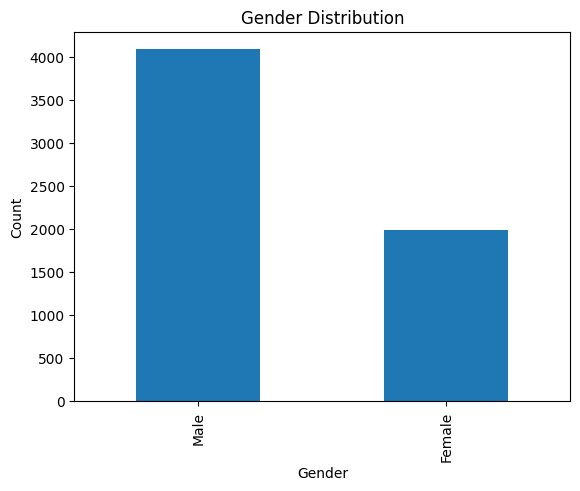

In [14]:

# Visualize gender distribution


df["gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

### Observation

- The dataset contains both male and female participants.
- Male participants are more numerous than female participants.

# Height distribution

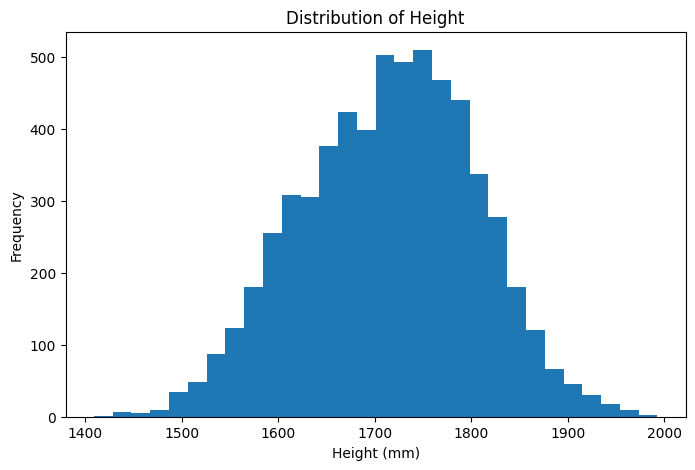

In [15]:
# Distribution of height

plt.figure(figsize=(8,5))

plt.hist(df["height_mm"], bins=30)

plt.title("Distribution of Height")
plt.xlabel("Height (mm)")
plt.ylabel("Frequency")

plt.show()

### Observation

- Most participants have heights between approximately **1600 mm and 1800 mm**.
- The frequency of participants decreases towards both the shorter and taller height ranges.

# Height vs weight

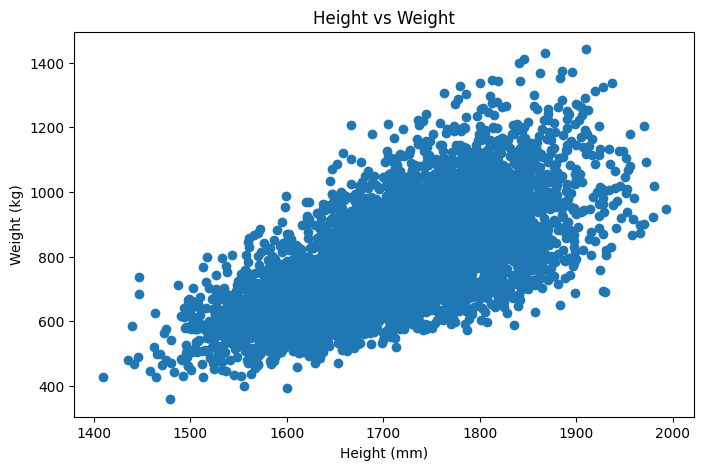

In [16]:
# Relationship between height and weight

plt.figure(figsize=(8,5))

plt.scatter(df["height_mm"], df["weight_kg"])

plt.title("Height vs Weight")
plt.xlabel("Height (mm)")
plt.ylabel("Weight (kg)")

plt.show()

### Observation

- There is a positive relationship between height and weight, where taller participants generally tend to have higher body weights.
- Most participants are concentrated around the middle ranges of both height and weight.

# Hip breadth vs gender

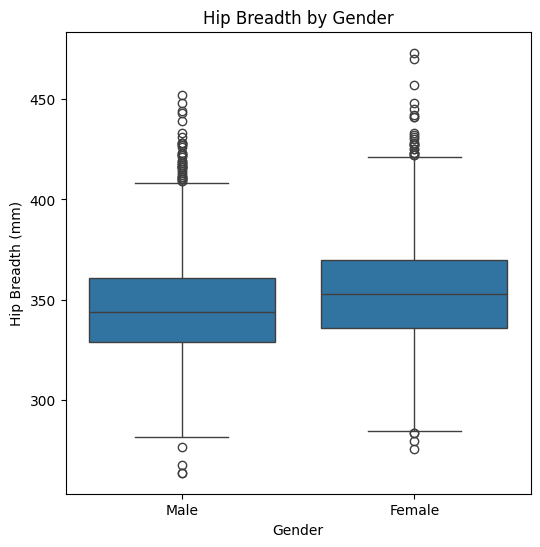

In [25]:
# Hip breadth by gender

plt.figure(figsize=(6,6))

sns.boxplot(x="gender", y="hip_breadth_mm", data=df)

plt.title("Hip Breadth by Gender")
plt.xlabel("Gender")
plt.ylabel("Hip Breadth (mm)")

plt.show()

### Observation

- Female participants generally have higher hip breadth measurements than male participants.
- Outliers are present in both gender groups.

# Correlation heatmap

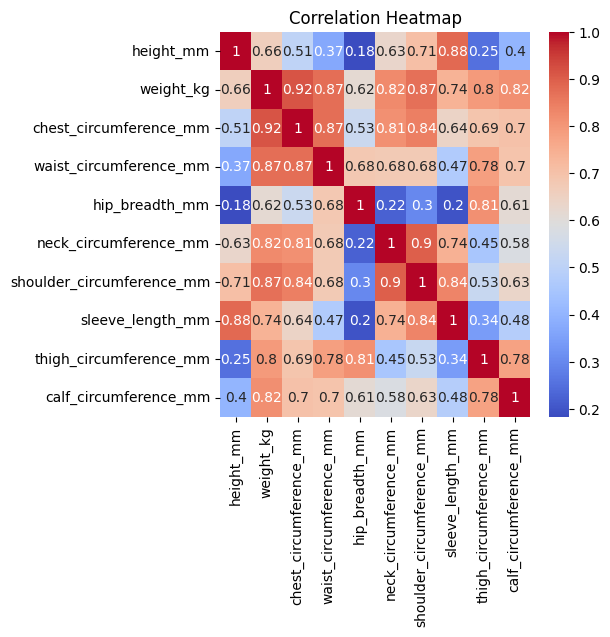

In [19]:
# Correlation heatmap

plt.figure(figsize=(5,5))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

### Observation

- Most body measurements are positively correlated, indicating that larger body dimensions tend to occur together.
- Neck circumference and shoulder circumference have a strong positive correlation (0.90), showing a close relationship between these upper-body measurements.